# AI-Powered Smart Retail & Customer Intelligence Platform

# Module 3: Customer Sentiment Analysis

1. Introduction
2. Objective
3. Install Libraries
4. Import Libraries
5. Load Dataset
6. Exploratory Data Analysis
7. Text Preprocessing
8. Feature Extraction (TF-IDF)
9. Train Sentiment Model
10. Model Evaluation
11. Save Model
12. Test Predictions
13. Conclusion

## Introduction

Customer feedback analysis is an important part of modern retail intelligence systems.

Sentiment analysis uses Natural Language Processing (NLP) techniques to automatically identify the emotional tone of customer reviews.

In this module, customer reviews are processed and classified into three categories:
- Positive
- Negative
- Neutral

The trained model can help businesses understand customer satisfaction and improve services.

## Objective

The objective of this module is to build a machine learning based sentiment analysis system that:

- Cleans and preprocesses customer review text.
- Converts text into numerical features.
- Trains a classification model.
- Predicts customer sentiment.
- Saves the trained model for API deployment.

In [1]:
!pip install nltk scikit-learn

In [2]:
import pandas as pd
import numpy as np

import re
import nltk

import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import pickle
import os

In [3]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

# Dataset Information

Dataset Name:
Women's E-Commerce Clothing Reviews

Author:
Nicapotato (Kaggle)

Source:
Kaggle

Description:
This dataset contains customer reviews and ratings for women's clothing products.
It is used to build a sentiment analysis model that classifies customer feedback
into Positive, Negative, and Neutral categories.

In [7]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Resume (4).pdf', '23BCE11316.pdf', 'Resume (3).pdf', 'Ganga Bhumi Club.pdf', 'Maths assignment.pdf', 'Document from Ishita Gautam', 'RESUME (2) (1).pdf', 'RESUME (2)-1.pdf', 'RESUME (2).pdf', 'Ishita Gautam - offer letter.pdf', 'Offer letter acceptance pdf.pdf', 'DOC-20250521-WA0015..pdf', 'Mini task 2.pdf', 'Installation .png', 'Hackhathon.png', 'wchl.png', 'Resume (2).pdf', 'Resume (1).pdf', 'StudentGradeHistory_23BCE11316_page-0002 (1).jpg', 'StudentGradeHistory_23BCE11316_page-0001.jpg', 'StudentGradeHistory_23BCE11316_page-0002.jpg', 'WhatsApp Image 2025-07-23 at 22.46.52_87fc5eb0.jpg', 'back.jpg', 'Front .jpg', '39.pdf', 'BlockseBlock internship certificate.pdf', 'question-2276389 (2).pdf', 'question-2276389 (1).pdf', 'question-2276389.pdf', 'question-2276389 (1).gdoc', 'question-2276389.gdoc', 'class 12th.pdf ..pdf', 'class11th.pdf', 'class 8th.pdf', 'Class 8th .pdf', 'Test Preparation Documents - to be shared with test takers.zip', 'Python Screening Task 2 .pdf', 'class 12th.

In [9]:
print(os.listdir("/content/drive/MyDrive/Smart-Retail-AI"))

['notebooks', 'datasets', 'models', 'outputs', 'images']


In [10]:
print(os.listdir("/content/drive/MyDrive/Smart-Retail-AI/datasets"))

['Womens Clothing E-Commerce Reviews.csv', 'product_images', 'customer_faces', 'lfw-deepfunneled']


In [11]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if "Womens" in file:
            print(os.path.join(root, file))

/content/drive/MyDrive/Smart-Retail-AI/datasets/Womens Clothing E-Commerce Reviews.csv


In [22]:
import pandas as pd

dataset_path = "/content/drive/MyDrive/Smart-Retail-AI/datasets/Womens Clothing E-Commerce Reviews.csv"

df = pd.read_csv(dataset_path)

df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [23]:
df.shape

(23486, 11)

In [24]:
df.columns

Index(['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating',
       'Recommended IND', 'Positive Feedback Count', 'Division Name',
       'Department Name', 'Class Name'],
      dtype='object')

In [25]:
df.isnull().sum()

,0
Unnamed: 0,0
Clothing ID,0
Age,0
Title,3810
Review Text,845
Rating,0
Recommended IND,0
Positive Feedback Count,0
Division Name,14
Department Name,14


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


In [28]:
df.isnull().sum()

,0
Unnamed: 0,0
Clothing ID,0
Age,0
Title,3810
Review Text,845
Rating,0
Recommended IND,0
Positive Feedback Count,0
Division Name,14
Department Name,14


In [29]:
df[['Review Text','Rating']].head(10)

,Review Text,Rating
0,Absolutely wonderful - silky and sexy and comf...,4
1,Love this dress! it's sooo pretty. i happene...,5
2,I had such high hopes for this dress and reall...,3
3,"I love, love, love this jumpsuit. it's fun, fl...",5
4,This shirt is very flattering to all due to th...,5
5,"I love tracy reese dresses, but this one is no...",2
6,I aded this in my basket at hte last mintue to...,5
7,"I ordered this in carbon for store pick up, an...",4
8,I love this dress. i usually get an xs but it ...,5
9,"I'm 5""5' and 125 lbs. i ordered the s petite t...",5


In [30]:
def sentiment_label(rating):

    if rating >= 4:
        return "Positive"

    elif rating == 3:
        return "Neutral"

    else:
        return "Negative"


df['Sentiment'] = df['Rating'].apply(sentiment_label)

In [31]:
df['Sentiment'].value_counts()

,count
Sentiment,
Positive,18208
Neutral,2871
Negative,2407


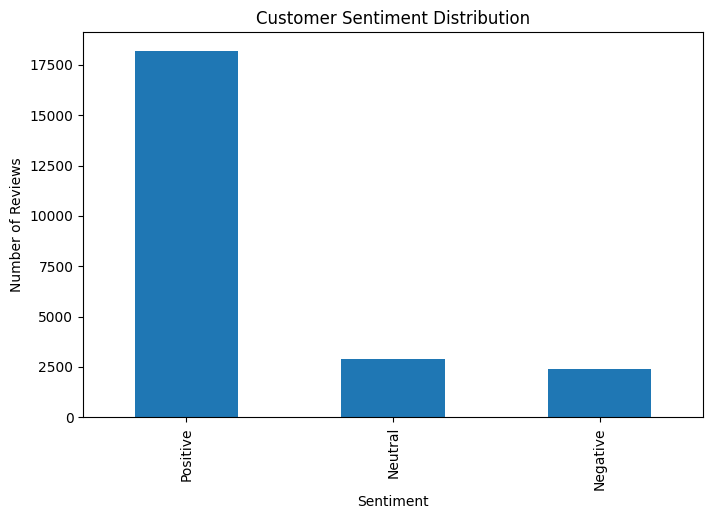

In [32]:
import matplotlib.pyplot as plt

df['Sentiment'].value_counts().plot(
    kind='bar',
    figsize=(8,5)
)

plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.title("Customer Sentiment Distribution")

plt.show()

In [33]:
df = df.dropna(subset=['Review Text'])

print("Remaining reviews:", len(df))

Remaining reviews: 22641


In [34]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [35]:
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove special characters and numbers
    text = re.sub(
        '[^a-zA-Z]',
        ' ',
        text
    )

    # Split words
    words = text.split()

    # Remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [36]:
df['Clean_Review'] = df['Review Text'].apply(clean_text)

In [37]:
df[['Review Text','Clean_Review']].head(10)

,Review Text,Clean_Review
0,Absolutely wonderful - silky and sexy and comf...,absolutely wonderful silky sexy comfortable
1,Love this dress! it's sooo pretty. i happene...,love dress sooo pretty happened find store gla...
2,I had such high hopes for this dress and reall...,high hope dress really wanted work initially o...
3,"I love, love, love this jumpsuit. it's fun, fl...",love love love jumpsuit fun flirty fabulous ev...
4,This shirt is very flattering to all due to th...,shirt flattering due adjustable front tie perf...
5,"I love tracy reese dresses, but this one is no...",love tracy reese dress one petite foot tall us...
6,I aded this in my basket at hte last mintue to...,aded basket hte last mintue see would look lik...
7,"I ordered this in carbon for store pick up, an...",ordered carbon store pick ton stuff always try...
8,I love this dress. i usually get an xs but it ...,love dress usually get x run little snug bust ...
9,"I'm 5""5' and 125 lbs. i ordered the s petite t...",lb ordered petite make sure length long typica...


In [38]:
df[df['Clean_Review']==""].shape

(0, 13)

In [39]:
clean_path = "/content/drive/MyDrive/Smart-Retail-AI/outputs/clean_reviews.csv"

df.to_csv(
    clean_path,
    index=False
)

print("Clean dataset saved!")

Clean dataset saved!


In [40]:
X = df['Clean_Review']
y = df['Sentiment']

In [41]:
print(X.head())
print(y.head())

0          absolutely wonderful silky sexy comfortable
1    love dress sooo pretty happened find store gla...
2    high hope dress really wanted work initially o...
3    love love love jumpsuit fun flirty fabulous ev...
4    shirt flattering due adjustable front tie perf...
Name: Clean_Review, dtype: object
0    Positive
1    Positive
2     Neutral
3    Positive
4    Positive
Name: Sentiment, dtype: object


In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 18112
Testing samples: 4529


In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [44]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(18112, 5000)
(4529, 5000)


In [45]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train_tfidf,
    y_train
)

print("Model training completed!")

Model training completed!


In [46]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.8196069772576727


In [47]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

    Negative       0.55      0.41      0.47       457
     Neutral       0.48      0.23      0.31       588
    Positive       0.87      0.97      0.92      3484

    accuracy                           0.82      4529
   macro avg       0.63      0.54      0.57      4529
weighted avg       0.79      0.82      0.79      4529



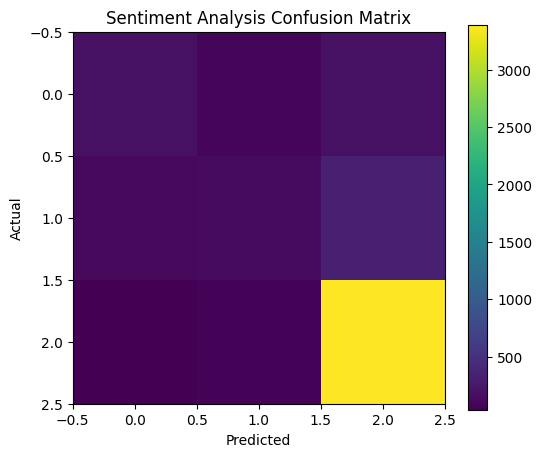

In [48]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Sentiment Analysis Confusion Matrix")

plt.colorbar()

plt.show()

In [49]:
import pickle
import os

In [50]:
model_folder = "/content/drive/MyDrive/Smart-Retail-AI/models"

os.makedirs(
    model_folder,
    exist_ok=True
)

In [51]:
model_path = os.path.join(
    model_folder,
    "sentiment_model.pkl"
)

with open(model_path, "wb") as file:
    pickle.dump(
        model,
        file
    )

print("Sentiment model saved successfully!")

Sentiment model saved successfully!


In [52]:
vectorizer_path = os.path.join(
    model_folder,
    "vectorizer.pkl"
)

with open(vectorizer_path, "wb") as file:
    pickle.dump(
        tfidf,
        file
    )

print("Vectorizer saved successfully!")

Vectorizer saved successfully!


In [53]:
print(os.listdir(model_folder))

['product_classifier.keras', 'face_db.pkl', 'sentiment_model.pkl', 'vectorizer.pkl']


In [54]:
with open(model_path, "rb") as file:
    loaded_model = pickle.load(file)


with open(vectorizer_path, "rb") as file:
    loaded_vectorizer = pickle.load(file)


print("Models loaded successfully!")

Models loaded successfully!


In [55]:
new_review = [
    "This dress is beautiful and the quality is amazing"
]

In [56]:
clean_review = [
    clean_text(new_review[0])
]

In [57]:
review_vector = loaded_vectorizer.transform(clean_review)

In [58]:
prediction = loaded_model.predict(review_vector)

print("Sentiment:", prediction[0])

Sentiment: Positive


# Conclusion

In this module, a customer sentiment analysis system was developed using Natural Language Processing.

The pipeline includes:
- Customer review preprocessing
- Text cleaning and normalization
- TF-IDF feature extraction
- Logistic Regression classification
- Sentiment prediction

The trained sentiment model and vectorizer were saved as pickle files for future integration with the FastAPI backend.